# Modeling SVM

[1] Data Split = 70:15:15

[2] Imbalance Class Handling = class_weight='balanced'

[3] Text Representation = TF-IDF (unigram + bigram)

[4] Feature Filtering = max_df=0.85; min_df=2; sublinear_tf=True

[5] Model = LinearSVC (One-vs-Rest / OvR)

[6] Max Iteration = 5000

[7] Validation = Stratified 3-Fold Cross Validation

[8] Evaluation Metrics = Classification Report (Macro F1-Scroe, Accuracy, Precision, Recall), Confusion Matrix, Inference Time

## Import Library

In [ ]:
# Library untuk serialisasi model dan operasi data/visualisasi
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Tools untuk split data dan evaluasi cross-validation
from sklearn.model_selection import (
    train_test_split,      # Split data menjadi train/val/test
    StratifiedKFold,       # K-Fold dengan distribusi kelas seimbang
    cross_val_score,       # Hitung skor dari cross-validation
)

# Tools untuk preprocessing label dan teks
from sklearn.preprocessing import LabelEncoder       # Encode label teks → numerik
from sklearn.feature_extraction.text import TfidfVectorizer  # Ubah teks → fitur TF-IDF

# Model klasifikasi berbasis SVM (linear)
from sklearn.svm import LinearSVC

# Metrics untuk evaluasi performa model
from sklearn.metrics import (
    classification_report,  # Precision, recall, F1-score per kelas
    confusion_matrix        # Matriks perbandingan prediksi vs label asli
)

# Menghubungkan Drive ke Colab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Load & Eksplorasi Data

In [ ]:
# Load dataset dari file CSV
path = '/content/drive/MyDrive/skripsi/svm_indobert/data/final_data/krl_complaints_preprocessed_4.csv'
df = pd.read_csv(path)

# Tampilkan 5 baris pertama untuk verifikasi data berhasil dimuat
print(df.head())

                                           full_text  \
0  @CommuterLine @suckislife_ @perkeretaapian Nge...   
1  @CommuterLine 5517 telat 50 menit kenapa masuk...   
2  @CommuterLine itu papan jadwal cisauk jalur 2 ...   
3  @CommuterLine @jalur5_ Klo kyk gini petugasnya...   
4  @CommuterLine Penataran Malang-SBY pukul jam 3...   

                                            text_svm  \
0             ngeri tangga tidak kuat banyak manusia   
1  angka telat angka menit masuk lokasi_stasiun a...   
2  papan jadwal lokasi_stasiun jalur angka tidak ...   
3  kalau begini tugas bantu astaga mau gendong ka...   
4  natar malang surabaya pukul jam 3an angka des ...   

                                           text_bert          label  
0  ngeri tangganya enggak kuat min itu banyak ban...       Keamanan  
1  5517 telat 50 menit kenapa masuk bks harusnya ...  Keterlambatan  
2  itu papan jadwal cisauk jalur 2 enggak update ...  Keterlambatan  
3  kalo kayak begini petugasnya bantu apa anji

In [ ]:
# Dictionary Label untuk mapping label kategori ke angka
label_map = {
    'Keterlambatan' : 0,
    'Pelayanan'     : 1,
    'Kepadatan'     : 2,
    'Keamanan'      : 3,
    'Kebersihan'    : 4
}

# Encode kolom 'label' menjadi numerik sesuai label_map
df['label_encoded'] = df['label'].map(label_map)

# Inisialisasi LabelEncoder untuk keperluan decoding/evaluasi
le = LabelEncoder()

# Set urutan kelas berdasarkan nilai encoding agar konsisten saat evaluasi
le.classes_ = np.array(sorted(label_map, key=label_map.get))

In [ ]:
# Ringkasan Dataset
print('  INFORMASI DATASET')
print(f"  Total sampel  : {len(df)}")
print(f"  Jumlah kelas  : {df['label'].nunique()}")
print(f"  Nama kelas    : {list(le.classes_)}")


  INFORMASI DATASET
  Total sampel  : 4918
  Jumlah kelas  : 5
  Nama kelas    : [np.str_('Keterlambatan'), np.str_('Pelayanan'), np.str_('Kepadatan'), np.str_('Keamanan'), np.str_('Kebersihan')]


In [ ]:
# Distribusi Kelas (Jumlah & Persentase)
# Hitung frekuensi tiap kelas
dist       = df['label'].value_counts()

# Hitung persentase tiap kelas
dist_pct   = dist / dist.sum() * 100

# Tampilkan tabel distribusi
dist_table = pd.DataFrame({
    'Frekuensi'     : dist,
    'Persentase (%)': dist_pct.round(2)
})
print('\n  Distribusi Label')
print(dist_table.to_string())


  Distribusi Label
               Frekuensi  Persentase (%)
label                                   
Keterlambatan       1627           33.08
Pelayanan           1276           25.95
Kepadatan           1236           25.13
Keamanan             527           10.72
Kebersihan           252            5.12


In [ ]:
# Hitung rasio imbalance (kelas terbesar dibanding terkecil)
ratio = dist.max() / dist.min()

print(f"\n  Imbalance Ratio (kelas terbesar / terkecil) : {ratio:.2f}x")
print(f"  Kelas mayoritas  : {dist.idxmax()} ({dist.max()} sampel)")
print(f"  Kelas minoritas  : {dist.idxmin()} ({dist.min()} sampel)")


  Imbalance Ratio (kelas terbesar / terkecil) : 6.46x
  Kelas mayoritas  : Keterlambatan (1627 sampel)
  Kelas minoritas  : Kebersihan (252 sampel)


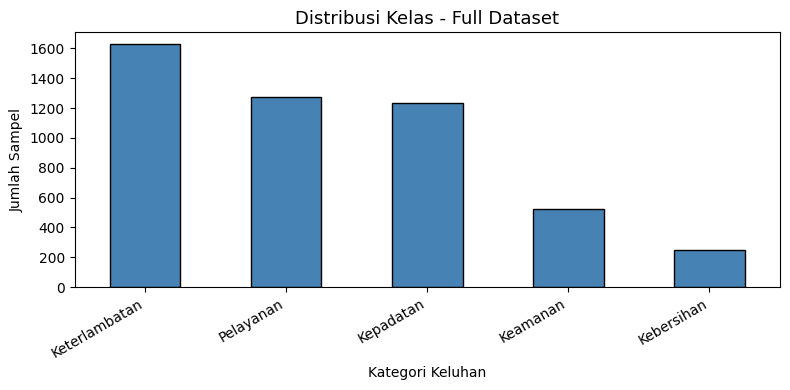

In [ ]:
# Visualisasi Distribusi Full Dataset
plt.figure(figsize=(8, 4))
dist.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Distribusi Kelas - Full Dataset', fontsize=13)
plt.xlabel('Kategori Keluhan')
plt.ylabel('Jumlah Sampel')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## Data Splitting

In [ ]:
# 70:15:15
# 1: Pisahkan 70% train dari 30% sisa (val + test)
X_train, X_temp, y_train, y_temp = train_test_split(
    df['text_svm'],                # Fitur teks yang sudah diproses
    df['label_encoded'],           # Label numerik
    test_size=0.30,                # 30% untuk val + test
    stratify=df['label_encoded'],  # Jaga proporsi kelas di setiap subset
    random_state=42                # Seed agar hasil konsisten (reproducible)
)

# 2: Bagi 30% sisa menjadi 15% val dan 15% test (50:50 dari sisa)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,  # 50% dari 30% = 15% dari total
    stratify=y_temp, # Menjaga agar distribusi kelas tetap seimbang di kedua subset
    random_state=42  # Seed agar hasil konsisten (reproducible)
)

In [ ]:
print(f"\n  Ukuran Split")
print(f"  Train : {len(X_train)} sampel ({len(X_train)/len(df)*100:.1f}%)")
print(f"  Val   : {len(X_val)} sampel ({len(X_val)/len(df)*100:.1f}%)")
print(f"  Test  : {len(X_test)} sampel ({len(X_test)/len(df)*100:.1f}%)")


  Ukuran Split
  Train : 3442 sampel (70.0%)
  Val   : 738 sampel (15.0%)
  Test  : 738 sampel (15.0%)


In [ ]:
def print_split_dist(y, split_name, le):
    '''Menampilkan jumlah dan persentase tiap kelas dalam satu subset data.'''
    series = pd.Series(le.inverse_transform(y)) # Decode label numerik → label asli
    counts = series.value_counts().sort_index() # Hitung jumlah per kelas (urut konsisten)
    total = len(y)

    print(f"\n[{split_name}] — {total} sampel")

    for label, count in counts.items():
        percentage = (count / total) * 100
        print(f"  {label:<20} : {count:>4} ({percentage:5.1f}%)")

Distribusi Kelas Per Split

[TRAIN  (70%)] — 3442 sampel
  Keamanan             :  369 ( 10.7%)
  Kebersihan           :  176 (  5.1%)
  Kepadatan            :  865 ( 25.1%)
  Keterlambatan        : 1139 ( 33.1%)
  Pelayanan            :  893 ( 25.9%)

[VAL    (15%)] — 738 sampel
  Keamanan             :   79 ( 10.7%)
  Kebersihan           :   38 (  5.1%)
  Kepadatan            :  186 ( 25.2%)
  Keterlambatan        :  244 ( 33.1%)
  Pelayanan            :  191 ( 25.9%)

[TEST   (15%)] — 738 sampel
  Keamanan             :   79 ( 10.7%)
  Kebersihan           :   38 (  5.1%)
  Kepadatan            :  185 ( 25.1%)
  Keterlambatan        :  244 ( 33.1%)
  Pelayanan            :  192 ( 26.0%)


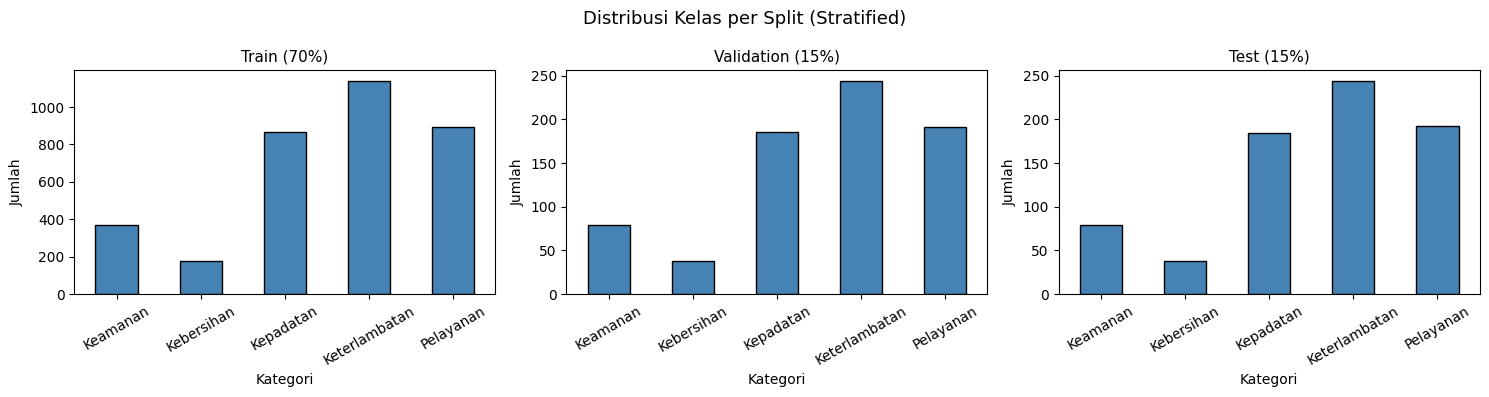

In [ ]:
print('Distribusi Kelas Per Split')
print_split_dist(y_train, 'TRAIN  (70%)', le)   # Distribusi data training
print_split_dist(y_val,   'VAL    (15%)', le)   # Distribusi data validasi
print_split_dist(y_test,  'TEST   (15%)', le)   # Distribusi data testing

# Visualisasi Distribusi Kelas Per Split [Bar Chart]
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 4))

# Daftar dataset split beserta judulnya
splits = [
    (y_train, 'Train (70%)'),        # Data training
    (y_val,   'Validation (15%)'),   # Data validasi
    (y_test,  'Test (15%)')          # Data testing
]

# Loop setiap subplot (ax) dan pasangan data split
for ax, (y_split, title) in zip(axes, splits):

    # Decode label numerik menjadi label asli (string)
    labels = le.inverse_transform(y_split)

    counts = (
        pd.Series(labels) # ubah ke Series
        .value_counts()   # hitung frekuensi
        .sort_index()     # urut berdasarkan nama label

    )

    # Membuat bar chart dari distribusi kelas
    counts.plot(
        kind='bar',        # tipe plot: bar chart
        ax=ax,             # plot ke subplot saat ini
        color='steelblue', # warna bar
        edgecolor='black'  # warna garis tepi bar
    )

    # Mengatur judul tiap subplot
    ax.set_title(title, fontsize=11)

    # Label sumbu X (kategori kelas)
    ax.set_xlabel('Kategori')

    # Label sumbu Y (jumlah data)
    ax.set_ylabel('Jumlah')

    # Mengatur rotasi label pada sumbu X agar tidak bertumpuk
    ax.tick_params(axis='x', rotation=30)

# Menambahkan judul utama untuk seluruh figure
fig.suptitle('Distribusi Kelas per Split (Stratified)', fontsize=13)

# Merapikan layout agar tidak saling bertabrakan
plt.tight_layout()

# Menampilkan plot ke layar
plt.show()

## Tokenisasi: TF-IDF
Fit hanya pada data train, sedangkan val/test hanya di-transform untuk mencegah data leakage

In [ ]:
vectorizer = TfidfVectorizer(
    sublinear_tf=True,     # Meredam dominasi pengulangan kata
    ngram_range=(1, 2),    # Unigram + Bigram (crucial untuk menyamai BERT)
    max_df=0.85,           # Hapus kata yang terlalu pasaran
    min_df=2,              # Hapus typo langka (noise)
)

# Fit (belajar kosakata) + transform hanya di train
X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf   = vectorizer.transform(X_val)
X_test_tfidf  = vectorizer.transform(X_test)

In [ ]:
print(f"\n  Informasi Shape TF-IDF Matrix:")
print(f"  Train : {X_train_tfidf.shape}")
print(f"  Val   : {X_val_tfidf.shape}")
print(f"  Test  : {X_test_tfidf.shape}")


  Informasi Shape TF-IDF Matrix:
  Train : (3442, 8003)
  Val   : (738, 8003)
  Test  : (738, 8003)


## Model Training with K-Fold Cross-Validation

In [ ]:
# Konfigurasi & Setup
# Nama Model
MODEL_NAME = 'LinearSVC_Baseline'

# Cross-Validation Setup (Stratified K-Fold)
cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

In [ ]:
# Inisialisasi Model
model = LinearSVC(
    multi_class='ovr',        # One-vs-Rest: satu kelas vs semua kelas lainnya
    class_weight='balanced',  # Mengatasi data imbalanced dengan penalti ekstra pada kelas minoritas
    max_iter=5000,            # Iterasi diperbesar untuk membantu konvergensi
    random_state=42           # Seed agar hasil konsisten
)

In [ ]:
# Cross-Validation (Train Set)
print(f"Menjalankan 3-Fold CV — {MODEL_NAME}...")

cv_scores = cross_val_score(
    estimator=model,           # Model yang digunakan
    X=X_train_tfidf,           # Fitur training
    y=y_train,                 # Label training
    cv=cv,                     # Skema cross-validation
    scoring='f1_macro',        # Metrik evaluasi
    n_jobs=-1                  # Gunakan semua core CPU
)

# Menampilkan hasil evaluasi per fold
print(f"  CV F1 Macro per fold : {np.round(cv_scores, 4)}")

# Menampilkan rata-rata dan standar deviasi
print(f"  CV F1 Macro Mean±Std : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

Menjalankan 3-Fold CV — LinearSVC_Baseline...
  CV F1 Macro per fold : [0.7845 0.7782 0.785 ]
  CV F1 Macro Mean±Std : 0.7826 ± 0.0031


## Final Model Trainig

In [ ]:
# Train Final Model (Full Train Set)
print(f'\nMelatih Model Final — {MODEL_NAME}...')

# Inisialisasi ulang model (best practice setelah CV)
final_model = LinearSVC(
    multi_class='ovr',
    class_weight='balanced',
    max_iter=5000,
    random_state=42
)

# Training model pada seluruh data training (70%)
final_model.fit(X_train_tfidf, y_train)


Melatih Model Final — LinearSVC_Baseline...


LinearSVC(class_weight='balanced', max_iter=5000, random_state=42)

## Validation Evaluation

In [ ]:
# Validation Prediction (15%)
val_preds = final_model.predict(X_val_tfidf)

In [ ]:
# Classification Report (Validation Set)
val_report_dict = classification_report(
    y_val,
    val_preds,
    target_names=le.classes_,
    output_dict=True  # untuk analisis lanjutan
)

print('\n Classification Report (Validation Set)')
print(
    classification_report(
        y_val,
        val_preds,
        target_names=le.classes_,
        digits=4
    )
)



 Classification Report (Validation Set)
               precision    recall  f1-score   support

Keterlambatan     0.8000    0.8525    0.8254       244
    Pelayanan     0.7251    0.6492    0.6851       191
    Kepadatan     0.7868    0.8333    0.8094       186
     Keamanan     0.7917    0.7215    0.7550        79
   Kebersihan     0.8947    0.8947    0.8947        38

     accuracy                         0.7832       738
    macro avg     0.7997    0.7903    0.7939       738
 weighted avg     0.7813    0.7832    0.7811       738



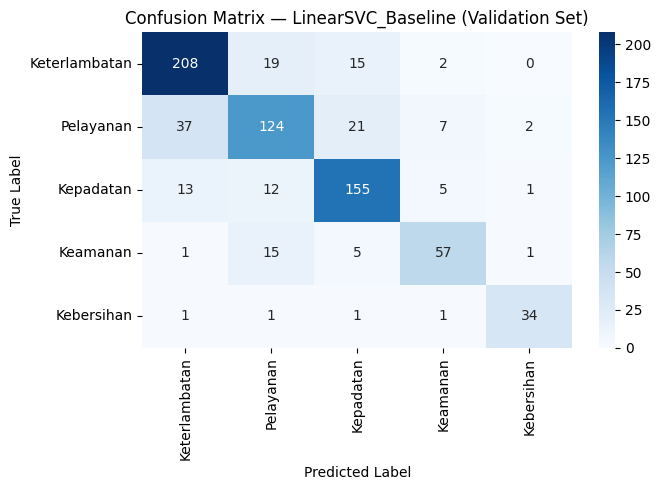

In [ ]:
# Confusion Matrix (Validation Set)
plt.figure(figsize=(7, 5))

sns.heatmap(
    confusion_matrix(y_val, val_preds),
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.title(f'Confusion Matrix — {MODEL_NAME} (Validation Set)', fontsize=12)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.tight_layout()
plt.show()

## Test Evaluation

In [ ]:
# Prediksi kelas pada data test (unseen data)
test_preds = final_model.predict(X_test_tfidf)

In [ ]:
# Classification Report (Test Set)
test_report_dict = classification_report(
    y_test,
    test_preds,
    target_names=le.classes_,
    output_dict=True  # untuk analisis lanjutan
)

print('\n Classification Report (Test Set)')
print(
    classification_report(
        y_test,
        test_preds,
        target_names=le.classes_,
        digits=4
    )
)


 Classification Report (Test Set)
               precision    recall  f1-score   support

Keterlambatan     0.8118    0.8484    0.8297       244
    Pelayanan     0.6978    0.6615    0.6791       192
    Kepadatan     0.7550    0.8162    0.7844       185
     Keamanan     0.7826    0.6835    0.7297        79
   Kebersihan     0.8750    0.7368    0.8000        38

     accuracy                         0.7683       738
    macro avg     0.7844    0.7493    0.7646       738
 weighted avg     0.7680    0.7683    0.7669       738



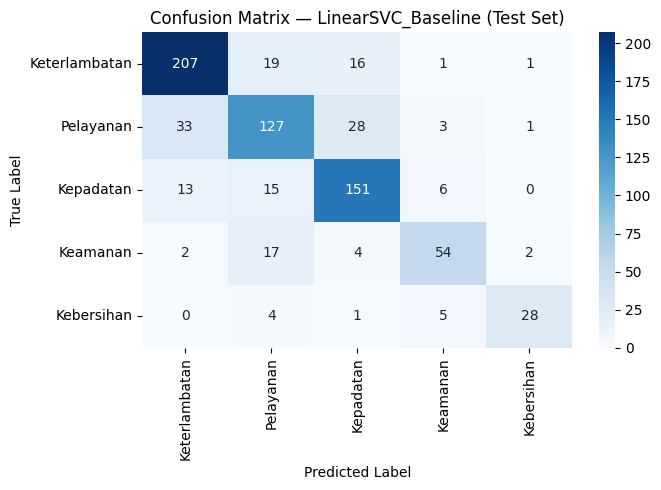

In [ ]:
# Confusion Matrix (Test Set)
plt.figure(figsize=(7, 5))

sns.heatmap(
    confusion_matrix(y_test, test_preds),
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.title(f'Confusion Matrix — {MODEL_NAME} (Test Set)', fontsize=12)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.tight_layout()
plt.show()

## Simpan Model

In [ ]:
# Lokasi penyimpanan model bundle (.pkl)
SAVE_PATH = '/content/drive/MyDrive/skripsi/svm_indobert/model/svm_linearsvc_data_2_2.pkl'

In [ ]:
# MODEL BUNDLE (EXPERIMENT ARTIFACTS)

# Simpan seluruh komponen penting (model, vectorizer, encoder, dan hasil evaluasi) ke satu bundle
bundle = {
    # Identitas eksperimen
    'model_name': MODEL_NAME,

    # Komponen utama model
    'model': final_model,
    'vectorizer': vectorizer,
    'label_encoder': le,

    # Hasil evaluasi
    'cv_scores': cv_scores,
    'validation_report': val_report_dict,
    'test_report': test_report_dict,

    # Metadata split data (untuk dokumentasi eksperimen)
    'split_info': {
        'train_size': len(y_train),
        'val_size': len(y_val),
        'test_size': len(y_test),
        'classes': list(le.classes_)
    }
}

In [ ]:
# Simpan bundle ke file .pkl agar bisa digunakan ulang tanpa retraining
with open(SAVE_PATH, 'wb') as f:
    pickle.dump(bundle, f)

# Konfirmasi lokasi file tersimpan
print(f"\n  Bundle tersimpan di: {SAVE_PATH}")


  Bundle tersimpan di: /content/drive/MyDrive/skripsi/svm_indobert/model/svm_linearsvc_data_2_2.pkl


## Inferensi Model

In [ ]:
# Import library untuk load model, data, dan evaluasi
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
# Load bundle model (model + vectorizer + encoder)
from google.colab import drive
drive.mount('/content/drive')

BUNDLE_PATH = '/content/drive/MyDrive/skripsi/svm_indobert/model/svm_linearsvc_data_2_2.pkl'

with open(BUNDLE_PATH, "rb") as f:
    bundle = pickle.load(f)

# Extract komponen model
loaded_model = bundle['model']
loaded_vec   = bundle['vectorizer']
loaded_le    = bundle['label_encoder']

# Load dataset eksternal dari CSV
df_ext = pd.read_csv('/content/drive/MyDrive/skripsi/svm_indobert/data/final_data/2026_krl_complaints_preprocessed_4.csv')

Mounted at /content/drive


In [ ]:
# Class Distribution (External Data)

dist_counts = df_ext["label"].value_counts()
dist_pct = dist_counts / dist_counts.sum() * 100

dist_table = pd.DataFrame({
    'Frekuensi': dist_counts,
    'Persentase (%)': dist_pct.round(2)
})

print('\nDistribusi Label (External Data):')
print(dist_table.to_string())



Distribusi Label (External Data):
               Frekuensi  Persentase (%)
label                                   
Keterlambatan        204           41.55
Pelayanan            125           25.46
Kepadatan            116           23.63
Keamanan              29            5.91
Kebersihan            17            3.46


In [ ]:
# Data Preparation
# Encode label asli
y_ext_true = loaded_le.transform(df_ext['label'])

# Transform teks → TF-IDF (tanpa fitting ulang)
X_ext_tfidf = loaded_vec.transform(df_ext['text_svm'])

In [ ]:
# Inference
ext_preds = loaded_model.predict(X_ext_tfidf)


 Classification Report (External Data)
               precision    recall  f1-score   support

Keterlambatan     0.8718    0.8333    0.8521       204
    Pelayanan     0.7304    0.6720    0.7000       125
    Kepadatan     0.7519    0.8621    0.8032       116
     Keamanan     0.4828    0.4828    0.4828        29
   Kebersihan     0.7368    0.8235    0.7778        17

     accuracy                         0.7780       491
    macro avg     0.7147    0.7347    0.7232       491
 weighted avg     0.7798    0.7780    0.7775       491



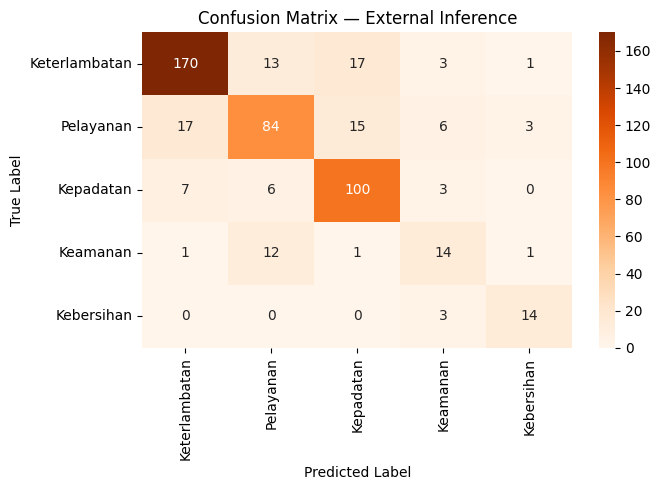

In [ ]:
# Evaluation

# Classification Report
ext_report_dict = classification_report(
    y_ext_true,
    ext_preds,
    target_names=loaded_le.classes_,
    output_dict=True
)

print('\n Classification Report (External Data)')
print(
    classification_report(
        y_ext_true,
        ext_preds,
        target_names=loaded_le.classes_,
        digits=4
    )
)

# Confusion Matrix
plt.figure(figsize=(7, 5))

sns.heatmap(
    confusion_matrix(y_ext_true, ext_preds),
    annot=True,
    fmt='d',
    cmap='Oranges',
    xticklabels=loaded_le.classes_,
    yticklabels=loaded_le.classes_
)

plt.title('Confusion Matrix — External Inference')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.tight_layout()
plt.show()

In [ ]:
# Summary Matrix
print('\n Ringkasan Metrik (External Data)')
print(f"  Accuracy        : {ext_report_dict['accuracy']:.4f}")
print(f"  Macro F1        : {ext_report_dict['macro avg']['f1-score']:.4f}")
print(f"  Weighted F1     : {ext_report_dict['weighted avg']['f1-score']:.4f}")
print(f"  Macro Precision : {ext_report_dict['macro avg']['precision']:.4f}")
print(f"  Macro Recall    : {ext_report_dict['macro avg']['recall']:.4f}")


 Ringkasan Metrik (External Data)
  Accuracy        : 0.7780
  Macro F1        : 0.7232
  Weighted F1     : 0.7775
  Macro Precision : 0.7147
  Macro Recall    : 0.7347


In [ ]:
# Inference Speed Benchmark
n_samples = X_ext_tfidf.shape[0]

start_time = time.perf_counter()
speed_preds = loaded_model.predict(X_ext_tfidf)
end_time = time.perf_counter()

total_time = end_time - start_time
time_per_sample = total_time / n_samples

print(f"  Total waktu        : {total_time:.4f} detik")
print(f"  Waktu per sampel   : {time_per_sample:.6f} detik")
print(f"  Kecepatan          : {n_samples / total_time:.2f} sampel/detik")

  Total waktu        : 0.0019 detik
  Waktu per sampel   : 0.000004 detik
  Kecepatan          : 252960.83 sampel/detik
